<a href="https://colab.research.google.com/github/SaurajeetAcharya/SMART-ATTENDANCE-SYSTEM/blob/main/Face_Recgnition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #Unpickling the data
import pickle

with open("/images.p","rb") as f:
  images=pickle.load(f)

with open("/labels.p","rb") as f:
  labels=pickle.load(f)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(images.shape)
print(images.shape)

(259, 100, 100)
(259, 100, 100)


In [ ]:
set(labels)

{np.str_('AKHILESH'), np.str_('SAURAJEET'), np.str_('SRIKANTA')}

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
labels=le.fit_transform(labels)

In [ ]:
set(labels)

{np.int64(0)}

In [ ]:
le.inverse_transform([0])

array(['AKHILESH'], dtype='<U9')

In [ ]:
p=len(set(labels))
print("Total number of Person :",p)

Total number of Person : 3


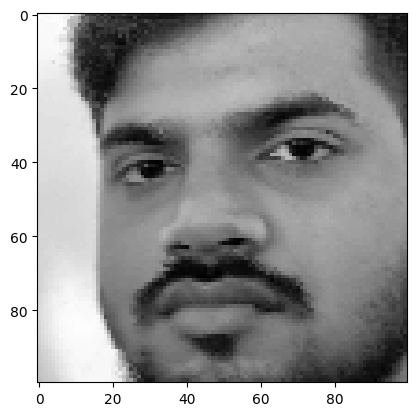

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(images[15],cmap='gray')
plt.show()

In [ ]:
import cv2

In [ ]:
def preprocessing (img):
  img=cv2.equalizeHist(img)
  img=img.reshape(100,100,1)
  img=img/255
  return img

In [ ]:
import numpy as np

In [ ]:
images=np.array(list(map(preprocessing,images)))
print("shape of input :",images.shape)

shape of input : (259, 100, 100, 1)


In [ ]:
from keras.utils import to_categorical
labels=to_categorical(labels)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Conv2D,MaxPooling2D,Flatten

In [ ]:
# Model Training
def Lenet_Model():
  model=Sequential()
  #Convolutional and ReLU Layers
  model.add(Conv2D(30,(5,5),input_shape=(100,100,1),activation='relu'))
  #Max Pooling Layer
  model.add(MaxPooling2D(pool_size=(2,2)))

  #Flatten Layer/Input Layer
  model.add(Flatten())

  #Hidden Layers
  model.add(Dense(100,activation='relu'))


  #Output Layer
  model.add(Dense(p,activation='softmax'))
  model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
  return model


In [ ]:
model=Lenet_Model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 30)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 69120)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     6,912,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,913,183 (26.37 MB)

 Trainable params: 6,913,183 (26.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
h=model.fit(images,labels,validation_split=0.1,epochs=10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - accuracy: 0.3779 - loss: 3.4730 - val_accuracy: 0.1154 - val_loss: 0.9975
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - accuracy: 0.6207 - loss: 0.7864 - val_accuracy: 1.0000 - val_loss: 0.5001
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step - accuracy: 0.9733 - loss: 0.3998 - val_accuracy: 1.0000 - val_loss: 0.0720
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - accuracy: 0.9720 - loss: 0.1857 - val_accuracy: 1.0000 - val_loss: 0.0170
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.9933 - loss: 0.0949 - val_accuracy: 1.0000 - val_loss: 0.0182
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.9936 - loss: 0.0485 - val_accuracy: 1.0000 - val_loss: 0.0093
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 351ms/step - accuracy: 1.0000 - loss: 0.0284 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - accuracy: 1.0000 - loss: 0.0132 - val_accuracy: 1.0000 - val_loss:

In [ ]:
model.save('recognization_model.h5')